### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.metrics import Accuracy

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Conv2D,Dense,AveragePooling2D,MaxPooling2D,Flatten,Dropout

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Data Gathering and Preprocessing

In [2]:
image_size = (224,224)

#Used Data Augmentation
data_generator = ImageDataGenerator(rescale=1./255,
                                    rotation_range=20,
                                    zoom_range=0.1,
                                    horizontal_flip=True,
                                    vertical_flip=True,
                                    validation_split=0.15)

train_generator = data_generator.flow_from_directory( r"D:\Velocity\Datasets\Image_Dataset\Casting_Dataset",
                                    target_size=image_size, 
                                    batch_size=32,
                                    class_mode='binary',
                                    subset='training')

val_generator = data_generator.flow_from_directory( r"D:\Velocity\Datasets\Image_Dataset\Casting_Dataset",
                                    target_size=image_size, 
                                    batch_size=32,
                                    class_mode='binary',
                                    subset='validation')


Found 680 images belonging to 2 classes.
Found 120 images belonging to 2 classes.


### Model Building

In [3]:
model = Sequential()

# --- CNN Layer-1 ----
model.add(Conv2D( filters=32, kernel_size= (3,3), strides= (1,1), activation = 'relu', input_shape = (224,224,3)))

model.add(MaxPooling2D(pool_size=(2,2)))
# ---- CNN Layer -2 ---
model.add(Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
# ---- CNN Layer -3 ---
model.add(Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

#--------MLP Layer----------
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dropout(0.3))
# Output layer
model.add(Dense(units= 1, activation = 'sigmoid')) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,768,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,825,345 (10.78 MB)

 Trainable params: 2,825,345 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer= 'adam', loss = 'binary_crossentropy', metrics= ['accuracy'])
histroy = model.fit(train_generator,validation_data= val_generator, epochs = 20, verbose= 1, batch_size=32)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6000 - loss: 0.6839 - val_accuracy: 0.7000 - val_loss: 0.6206
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6941 - loss: 0.6015 - val_accuracy: 0.6833 - val_loss: 0.5976
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7294 - loss: 0.5775 - val_accuracy: 0.7083 - val_loss: 0.5567
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7368 - loss: 0.5647 - val_accuracy: 0.7333 - val_loss: 0.5645
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7456 - loss: 0.5291 - val_accuracy: 0.7250 - val_loss: 0.5520
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7500 - loss: 0.5184 - val_accuracy: 0.7000 - val_loss: 0.6135
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7809 - loss: 0.4793 - val_accuracy: 0.7583 - val_loss: 0.5360
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7779 - loss: 0.4769 - val_accuracy: 0.7500 - val_loss:

In [5]:
histroy.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

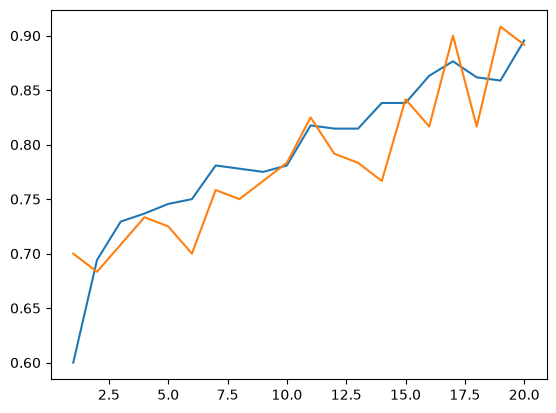

In [6]:
epoch_range = range(1,21)
plt.plot(epoch_range,histroy.history['accuracy'])
plt.plot(epoch_range,histroy.history['val_accuracy'])

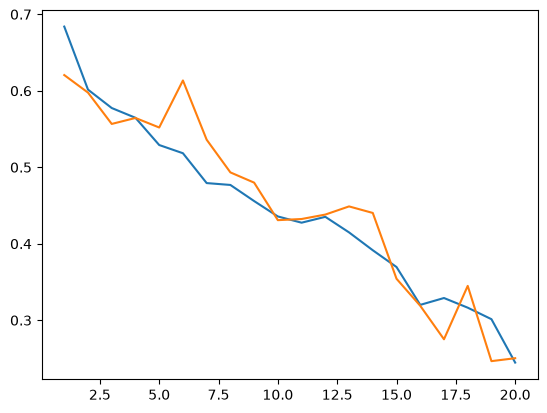

In [7]:
plt.plot(epoch_range,histroy.history['loss'])
plt.plot(epoch_range,histroy.history['val_loss'])

#### Results
-> Not training model further then 20  epochs cause the models best results are coming between epoch 19-20 after that model not 
   procurring good results

### Model Testing

In [8]:
print("Keras Class Mapping:", train_generator.class_indices)

Keras Class Mapping: {'def_front': 0, 'ok_front': 1}


In [35]:
# Load and preprocess testing image
img_path = r"D:\Velocity\Datasets\Image_Dataset\Casting_Dataset\ok_front\cast_ok_0_2784.jpeg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
test_array = img_array.reshape(1, 224, 224, 3)

# Make Prediction (Prediction > 0.5 leans towards class 1: 'ok_front')
prediction = model.predict(test_array)[0][0]

# Correct class mapping
predicted_class_name = 'Unit Condition is Good' if prediction > 0.5 else 'Unit Is Defective'
defective_probability = (1 - prediction) * 100 if prediction <= 0.5 else prediction * 100

print(f"Model Confidence: {defective_probability:.2f}%")
print(f"Predicted Image Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Model Confidence: 68.15%
Predicted Image Class is: Unit Condition is Good


In [36]:
# Load and preprocess testing image
img_path = r"D:\Velocity\Datasets\Image_Dataset\Casting_Dataset\ok_front\cast_ok_0_2482.jpeg"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
test_array = img_array.reshape(1, 224, 224, 3)

# Make Prediction (Prediction > 0.5 leans towards class 1: 'ok_front')
prediction = model.predict(test_array)[0][0]

# Correct class mapping
predicted_class_name = 'Unit Condition is Good' if prediction > 0.5 else 'Unit Is Defective'
defective_probability = (1 - prediction) * 100 if prediction <= 0.5 else prediction * 100

print(f"Model Confidence: {defective_probability:.2f}%")
print(f"Predicted Image Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Model Confidence: 74.80%
Predicted Image Class is: Unit Is Defective


### Save Model

In [29]:
import json
# ---- Save model---
model.save("Manufacturing_Defect_Detection.keras")
# ---Save class names---
with open("","w") as f:
    json.dump(class_names,f)
